# Линейная регрессия — EdStatsCountry

**Задача:** предсказать год последних торговых данных (`Latest trade data`) по году последних промышленных данных (`Latest industrial data`).

**Идея:** если страна недавно обновила промышленную статистику — скорее всего она обновила и торговую. Проверим это через линейную регрессию.

---

## 1. Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 2. Загрузка и подготовка данных

In [2]:
marks = pd.read_csv('EdStatsCountry.csv')

print(f'Загружено строк: {len(marks)}, колонок: {len(marks.columns)}')
marks.head()

Загружено строк: 241, колонок: 32


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


In [3]:
# Берём только нужные колонки и убираем строки с пустыми значениями
df = marks[['Latest industrial data', 'Latest trade data']].dropna()

print(f'Строк после удаления пустых: {len(df)}')
print()
print(df.describe())

Строк после удаления пустых: 104

       Latest industrial data  Latest trade data
count              104.000000         104.000000
mean              2008.086538        2011.673077
std                  2.633284           1.118618
min               2000.000000        2003.000000
25%               2007.750000        2012.000000
50%               2009.000000        2012.000000
75%               2010.000000        2012.000000
max               2010.000000        2012.000000


## 3. Разбивка на обучающую и тестовую выборки

In [4]:
# X — признак (то что подаём на вход модели)
# y — целевая переменная (то что хотим предсказать)
X = df[['Latest industrial data']]  # двойные скобки — pandas ожидает таблицу, не столбец
y = df['Latest trade data']

# 80% данных — для обучения, 20% — для проверки
# random_state=42 — фиксирует случайность, чтобы результат был одинаковым при каждом запуске
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Обучающая выборка:  {len(X_train)} стран')
print(f'Тестовая выборка:   {len(X_test)} стран')

Обучающая выборка:  83 стран
Тестовая выборка:   21 стран


## 4. Обучение модели

In [5]:
model = LinearRegression()

# Здесь происходит обучение — модель подбирает коэффициенты
model.fit(X_train, y_train)

print(f'Коэффициент (наклон прямой): {model.coef_[0]:.4f}')
print(f'Свободный член (intercept):  {model.intercept_:.4f}')
print()
print('Формула: Latest trade data = '
      f'{model.coef_[0]:.4f} * Latest industrial data + {model.intercept_:.4f}')

Коэффициент (наклон прямой): -0.0226
Свободный член (intercept):  2057.0807

Формула: Latest trade data = -0.0226 * Latest industrial data + 2057.0807


## 5. Предсказания и оценка качества

In [6]:
# Делаем предсказания на тестовой выборке
y_pred = model.predict(X_test)

# MAE — средняя ошибка в годах
mae = mean_absolute_error(y_test, y_pred)

# R² — насколько хорошо модель объясняет данные (от 0 до 1, чем выше тем лучше)
r2 = r2_score(y_test, y_pred)

# Baseline MAE — ошибка если всегда предсказывать среднее (без модели)
baseline_mae = mean_absolute_error(y_test, [y_train.mean()] * len(y_test))

print('=' * 50)
print('РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ')
print('=' * 50)
print(f'MAE модели:      {mae:.2f} лет')
print(f'MAE без модели:  {baseline_mae:.2f} лет  (если всегда говорить "среднее")')
print(f'R² score:        {r2:.4f}')
print()
if mae < baseline_mae:
    print(f'✓ Модель лучше baseline на {baseline_mae - mae:.2f} лет')
else:
    print('✗ Модель не лучше чем просто среднее — данных слишком мало')

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
MAE модели:      0.47 лет
MAE без модели:  0.45 лет  (если всегда говорить "среднее")
R² score:        -0.2788

✗ Модель не лучше чем просто среднее — данных слишком мало


## 6. Визуализация

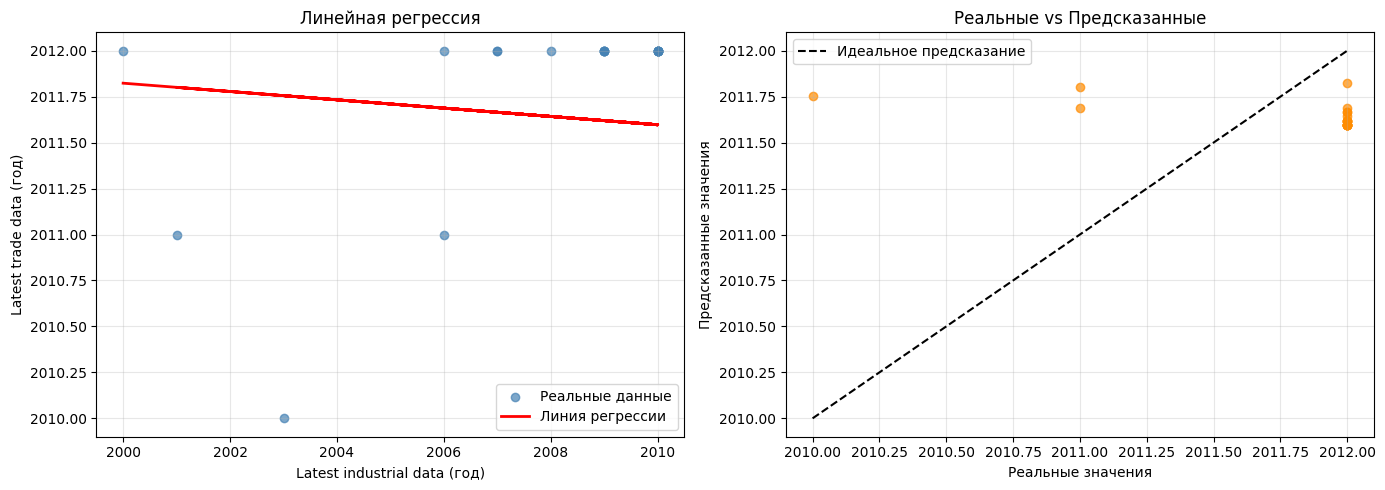

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── График 1: данные + линия регрессии ──────────────────────────────────────
ax1 = axes[0]
ax1.scatter(X_test, y_test, color='steelblue', alpha=0.7, label='Реальные данные')
ax1.plot(X_test, y_pred, color='red', linewidth=2, label='Линия регрессии')
ax1.set_xlabel('Latest industrial data (год)')
ax1.set_ylabel('Latest trade data (год)')
ax1.set_title('Линейная регрессия')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── График 2: реальные vs предсказанные ─────────────────────────────────────
ax2 = axes[1]
ax2.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
# Идеальная линия — если предсказание = реальность
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Идеальное предсказание')
ax2.set_xlabel('Реальные значения')
ax2.set_ylabel('Предсказанные значения')
ax2.set_title('Реальные vs Предсказанные')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Пример предсказания для новой страны

In [ ]:
# Допустим у новой страны последние промышленные данные за 2010 год
# Какой год торговых данных предскажет модель?

new_country = pd.DataFrame({'Latest industrial data': [2005, 2010, 2015, 2020]})
predictions = model.predict(new_country)

print('Примеры предсказаний:')
print('-' * 45)
for ind_year, trade_year in zip(new_country['Latest industrial data'], predictions):
    print(f'  Промышленные данные за {int(ind_year)} → торговые: {trade_year:.1f}')

Примеры предсказаний:
---------------------------------------------
  Промышленные данные за 2005 → торговые: 2011.7
  Промышленные данные за 2010 → торговые: 2011.6
  Промышленные данные за 2015 → торговые: 2011.5
  Промышленные данные за 2020 → торговые: 2011.4


## 8. Итоги

| Метрика | Значение |
|---|---|
| MAE модели | показывает насколько ошибается в годах |
| R² score | насколько хорошо объясняет данные (0–1) |
| Baseline MAE | ошибка без модели (просто среднее) |

**Как читать R²:**
- `0.0` — модель бесполезна, не лучше среднего
- `0.5` — объясняет половину разброса данных  
- `1.0` — идеальное предсказание (в реальности не бывает)

> **Примечание:** датасет маленький (~100 строк с заполненными значениями), поэтому результаты могут быть скромными. Для серьёзного ML нужно больше данных и больше признаков.